In [295]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor

In [ ]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/school_perf_pred"

# Data

In [277]:
def prep_df(df: pd.DataFrame):
    df = df.drop(["SampleID", "Exam_Score"], axis=1, errors='ignore')

    obj_col = df.select_dtypes(include=["object"])
    for col in obj_col:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
    df = df.drop(obj_col, axis=1)

    return df

In [278]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = prep_df(df)
df.head()

,SampleID,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,...,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,2276,18,95,Low,High,No,7,96,Medium,Yes,...,Medium,High,Private,Positive,4,Yes,High School,Moderate,Male,70
1,4604,16,89,High,Medium,Yes,8,58,Low,Yes,...,Low,Medium,Public,Neutral,3,No,College,Moderate,Male,67
2,2203,16,69,Medium,High,Yes,6,55,Medium,Yes,...,Medium,High,Public,Negative,1,No,High School,Moderate,Male,62
3,472,11,65,Medium,High,No,7,78,Medium,Yes,...,Low,Medium,Public,Neutral,3,No,Postgraduate,Near,Female,63
4,4061,21,95,Medium,High,Yes,8,57,Low,No,...,Low,Medium,Public,Positive,3,No,High School,Near,Male,69


(array([ 246., 1385., 2632.,  741.,   56.,   11.,    7.,    9.,    7.,
           8.]),
 array([ 57. ,  61.4,  65.8,  70.2,  74.6,  79. ,  83.4,  87.8,  92.2,
         96.6, 101. ]),
 <BarContainer object of 10 artists>)

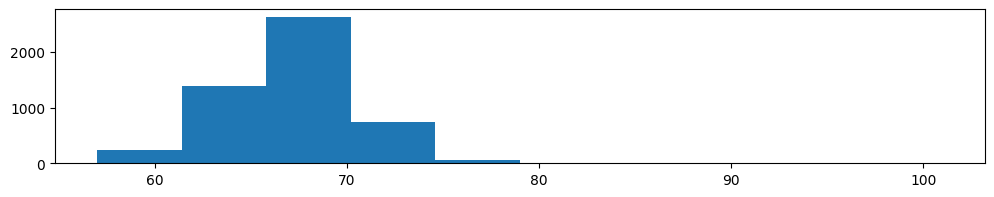

In [279]:
plt.figure(figsize=(12, 2))
plt.hist(df["Exam_Score"])

# Model 

In [280]:
X_train, X_test, y_train, y_test = train_test_split(df_train, df["Exam_Score"], test_size=0.2, random_state=seed)

In [281]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    cv_score = -(cv.mean() - cv.std()).item()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = root_mean_squared_error(y_test, preds)

    return cv_score, score

In [292]:
ridge = Pipeline(steps=[("scaler", StandardScaler()), ("model", Ridge(alpha=10))])

evaluate(ridge)

(2.168146530926554, 2.447900645415476)

In [293]:
svr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearSVR(C=10, epsilon=0.1, max_iter=5000, random_state=seed))
])

evaluate(svr)

/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


(2.1638365617592883, 2.459461781668508)

In [ ]:
cb = CatBoostRegressor(
    random_seed=seed, verbose=0, iterations=1000, learning_rate=0.05, depth=6
)

cb_param_grid = {
    "iterations": [500, 1000],
    "learning_rate": [0.01, 0.05],
    "depth": [4, 6],
}
cb_grid = GridSearchCV(
    cb, cb_param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
cb_grid.fit(X_train, y_train)
cb = cb_grid.best_estimator_
print(f"Best CB params: {cb_grid.best_params_}")

evaluate(cb)

/home/stefan/.local/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CB params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


(2.2340834208008165, 2.5056244293908154)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1, max_depth=10)

rf_param_grid = {"n_estimators": [100, 200], "max_depth": [8, 10, None]}
rf_grid = GridSearchCV(
    rf, rf_param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")

evaluate(rf)

Best RF params: {'max_depth': None, 'n_estimators': 200}


(2.5514359049933373, 2.8241552176602838)

In [297]:
stack = StackingRegressor(
    estimators=[("ridge", ridge), ("svr", svr), ("cb", cb), ("rf", rf)],
    final_estimator=Ridge(alpha=1.0, random_state=seed),
    cv=5,
    n_jobs=-1,
)

evaluate(stack)

/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear fail

(2.154503787247917, 2.4533264099826124)

In [298]:
model = stack

stack.fit(df_train, df["Exam_Score"])

/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/stefan/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


StackingRegressor(cv=5,
                  estimators=[('ridge',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('model', Ridge(alpha=10))])),
                              ('svr',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('model',
                                                LinearSVR(C=10, epsilon=0.1,
                                                          max_iter=5000,
                                                          random_state=42))])),
                              ('cb',
                               <catboost.core.CatBoostRegressor object at 0x7fe7fc4072f0>),
                              ('rf',
                               RandomForestRegressor(n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42))],
                  final_estimator=Ridge(random_state=42), n_jobs=-1)

# Submission

In [299]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]

df_test = prep_df(df_test)

In [300]:
submission["Exam_Score"] = model.predict(df_test)
submission.head()

,SampleID,Exam_Score
0,2719,73.781264
1,4276,65.994046
2,4142,70.558902
3,1200,71.925279
4,4547,67.699060


In [301]:
submission.to_csv(f"{root_path}/submission.csv", index=False)